In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, random_split, DataLoader
import numpy as np

transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)

all_data = torch.utils.data.ConcatDataset([train_set, test_set])
all_targets = np.array(train_set.targets + test_set.targets)

binary_indices = np.where((all_targets == 0) | (all_targets == 1))[0]
binary_dataset = Subset(all_data, binary_indices)

total_len = len(binary_dataset)
train_len = int(0.70 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

cifar_train, cifar_val, cifar_test = random_split(
    binary_dataset, [train_len, val_len, test_len], 
    generator=torch.Generator().manual_seed(42)
)

cifar_train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=2)
cifar_val_loader = DataLoader(cifar_val, batch_size=64, shuffle=False, num_workers=2)
cifar_test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=2)

print(f"Data Pipeline CIFAR-10 SUKSES!")
print(f"Train: {len(cifar_train)} | Val: {len(cifar_val)} | Test: {len(cifar_test)}")

100%|██████████| 170M/170M [00:06<00:00, 27.8MB/s] 


Data Pipeline CIFAR-10 SUKSES!
Train: 8400 | Val: 1800 | Test: 1800


In [2]:
transform_cvd = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_pet_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data_pet', download=True, transform=transform_cvd
)

labels = np.array(full_pet_dataset._labels)
cat_indices = np.where(labels < 12)[0][:500] 
dog_indices = np.where(labels >= 12)[0][:500]
cvd_indices = np.concatenate([cat_indices, dog_indices])
cvd_binary_dataset = Subset(full_pet_dataset, cvd_indices)

for idx in cvd_indices:
    original_label = full_pet_dataset._labels[idx]
    full_pet_dataset._labels[idx] = 0 if original_label < 12 else 1

total_len_cvd = len(cvd_binary_dataset)
train_len_cvd = int(0.70 * total_len_cvd)
val_len_cvd = int(0.15 * total_len_cvd)
test_len_cvd = total_len_cvd - train_len_cvd - val_len_cvd

cvd_train, cvd_val, cvd_test = random_split(
    cvd_binary_dataset, [train_len_cvd, val_len_cvd, test_len_cvd],
    generator=torch.Generator().manual_seed(42)
)

cvd_train_loader = DataLoader(cvd_train, batch_size=32, shuffle=True, num_workers=2)
cvd_val_loader = DataLoader(cvd_val, batch_size=32, shuffle=False, num_workers=2)
cvd_test_loader = DataLoader(cvd_test, batch_size=32, shuffle=False, num_workers=2)

print("Data Pipeline Cats vs Dogs SUKSES 100%!")
print(f"Train: {len(cvd_train)} | Val: {len(cvd_val)} | Test: {len(cvd_test)}")

100%|██████████| 792M/792M [00:03<00:00, 202MB/s]  
100%|██████████| 19.2M/19.2M [00:00<00:00, 102MB/s] 


Data Pipeline Cats vs Dogs SUKSES 100%!
Train: 700 | Val: 150 | Test: 150


In [3]:
import torch.nn as nn

class CifarCNNFromScratch(nn.Module):
    def __init__(self):
        super(CifarCNNFromScratch, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), 

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_scratch = CifarCNNFromScratch().to(device)
print("Sasis Model CNN From Scratch Berhasil Dipasang!")

Sasis Model CNN From Scratch Berhasil Dipasang!


In [4]:
import torchvision.models as models

model_transfer = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model_transfer.parameters():
    param.requires_grad = False

num_ftrs = model_transfer.classifier[1].in_features
model_transfer.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, 2)
)

model_transfer = model_transfer.to(device)
print("Sasis Transfer Learning MobileNetV2 Sukses Terkonfigurasi Tanpa Warning!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 198MB/s]

Sasis Transfer Learning MobileNetV2 Sukses Terkonfigurasi Tanpa Warning!


In [5]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Loss -> Train: {train_loss:.4f} | Val: {val_loss:.4f} || Acc -> Train: {train_acc:.4f} | Val: {val_acc:.4f}")
        
    return history
print("Mesin Loop Pelatihan Modular Siap Digunakan!")

Mesin Loop Pelatihan Modular Siap Digunakan!


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

print("=== MEMULAI TRAINING: CNN FROM SCRATCH (CIFAR-10) ===")
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
history_scratch = train_model(
    model_scratch, cifar_train_loader, cifar_val_loader, 
    criterion, optimizer_scratch, epochs=5
)

=== MEMULAI TRAINING: CNN FROM SCRATCH (CIFAR-10) ===


Epoch 1/5 [Train]: 100%|██████████| 132/132 [00:03<00:00, 41.03it/s]


Loss -> Train: 0.3855 | Val: 0.2412 || Acc -> Train: 0.8346 | Val: 0.8983


Epoch 2/5 [Train]: 100%|██████████| 132/132 [00:01<00:00, 81.59it/s]


Loss -> Train: 0.2366 | Val: 0.1770 || Acc -> Train: 0.9051 | Val: 0.9322


...

Loss -> Train: 0.1929 | Val: 0.1545 || Acc -> Train: 0.9195 | Val: 0.9350


Epoch 4/5 [Train]: 100%|██████████| 132/132 [00:01<00:00, 85.09it/s]


Loss -> Train: 0.1545 | Val: 0.1355 || Acc -> Train: 0.9386 | Val: 0.9500


Epoch 5/5 [Train]: 100%|██████████| 132/132 [00:01<00:00, 88.87it/s]


Loss -> Train: 0.1323 | Val: 0.1287 || Acc -> Train: 0.9479 | Val: 0.9506


In [7]:
print("\n=== MEMULAI TRAINING: TRANSFER LEARNING (CATS VS DOGS) ===")
optimizer_transfer = optim.Adam(model_transfer.parameters(), lr=0.001)
history_transfer = train_model(
    model_transfer, cvd_train_loader, cvd_val_loader, 
    criterion, optimizer_transfer, epochs=5
)


=== MEMULAI TRAINING: TRANSFER LEARNING (CATS VS DOGS) ===


Epoch 1/5 [Train]: 100%|██████████| 22/22 [00:02<00:00, 10.00it/s]


Loss -> Train: 0.5648 | Val: 0.4299 || Acc -> Train: 0.7500 | Val: 0.8400


Epoch 2/5 [Train]: 100%|██████████| 22/22 [00:02<00:00, 10.77it/s]


Loss -> Train: 0.3857 | Val: 0.3482 || Acc -> Train: 0.8714 | Val: 0.8600


...

Loss -> Train: 0.3154 | Val: 0.3087 || Acc -> Train: 0.8914 | Val: 0.8800


Epoch 4/5 [Train]: 100%|██████████| 22/22 [00:02<00:00, 10.76it/s]


Loss -> Train: 0.3142 | Val: 0.2943 || Acc -> Train: 0.8857 | Val: 0.8867


Epoch 5/5 [Train]: 100%|██████████| 22/22 [00:02<00:00, 10.26it/s]


Loss -> Train: 0.2677 | Val: 0.2688 || Acc -> Train: 0.9129 | Val: 0.8933


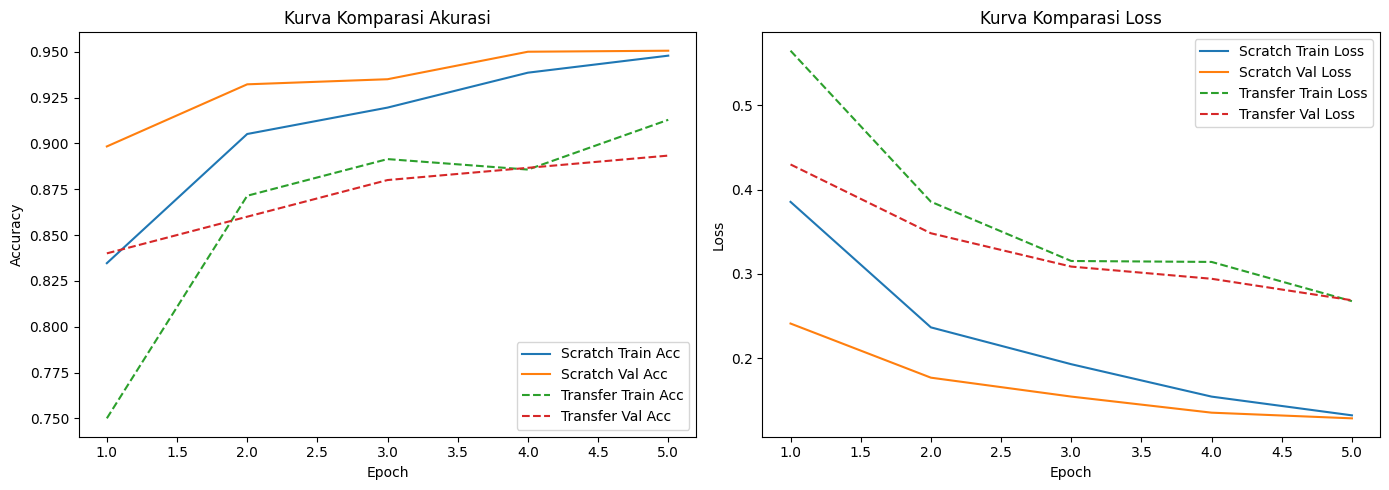

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, 6)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch['train_acc'], label='Scratch Train Acc')
plt.plot(epochs_range, history_scratch['val_acc'], label='Scratch Val Acc')
plt.plot(epochs_range, history_transfer['train_acc'], label='Transfer Train Acc', linestyle='--')
plt.plot(epochs_range, history_transfer['val_acc'], label='Transfer Val Acc', linestyle='--')
plt.title('Kurva Komparasi Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch['train_loss'], label='Scratch Train Loss')
plt.plot(epochs_range, history_scratch['val_loss'], label='Scratch Val Loss')
plt.plot(epochs_range, history_transfer['train_loss'], label='Transfer Train Loss', linestyle='--')
plt.plot(epochs_range, history_transfer['val_loss'], label='Transfer Val Loss', linestyle='--')
plt.title('Kurva Komparasi Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate_and_matrix(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"\n=== METRIK EVALUASI TESTING: {model_name} ===")
    print(f"Akurasi Data Akhir (Testing): {acc * 100:.2f}%")
    print("Confusion Matrix:")
    print(cm)

evaluate_and_matrix(model_scratch, cifar_test_loader, "CNN From Scratch")
evaluate_and_matrix(model_transfer, cvd_test_loader, "Transfer Learning")


=== METRIK EVALUASI TESTING: CNN From Scratch ===
Akurasi Data Akhir (Testing): 95.67%
Confusion Matrix:
[[882  43]
 [ 35 840]]

=== METRIK EVALUASI TESTING: Transfer Learning ===
Akurasi Data Akhir (Testing): 93.33%
Confusion Matrix:
[[68  3]
 [ 7 72]]
